## Load dataset

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization,GlobalAveragePooling2D
# 1d-textual data(sequential), 2d-images(non-sequential data), 3d-videos
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Data preprocessing

In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 
BASE_DIR = "/kaggle/input/melanoma-cancer-dataset"
ORIGINAL_TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')
 
# Create new directories
WORK_DIR = '/kaggle/working/melanoma_data'
TRAIN_DIR = os.path.join(WORK_DIR, 'train')
VAL_DIR = os.path.join(WORK_DIR, 'val')
 
for split in ['train', 'val']:
    for class_name in ['Benign', 'Malignant']:
        os.makedirs(os.path.join(WORK_DIR, split, class_name), exist_ok=True)
 
print("Creating 70-20-10 split...")
 
# Split original training data
for class_name in ['Benign', 'Malignant']:
    class_dir = os.path.join(ORIGINAL_TRAIN_DIR, class_name)
    images = os.listdir(class_dir)
    
    print(f"\n{class_name}: {len(images)} images")
    
    # 70-22 split (22% validation since ~10% is in test)
    train_split, val_split = train_test_split(
        images, test_size=0.22, random_state=42, shuffle=True
    )
    
    # Copy files
    for img in train_split:
        src = os.path.join(class_dir, img)
        dst = os.path.join(TRAIN_DIR, class_name, img)
        shutil.copy2(src, dst)
    
    for img in val_split:
        src = os.path.join(class_dir, img)
        dst = os.path.join(VAL_DIR, class_name, img)
        shutil.copy2(src, dst)
    
    print(f"  → Train: {len(train_split)}, Val: {len(val_split)}")
 
print("\n" + "="*60)
print("DATASET SPLIT SUMMARY")
print("="*60)
 
train_total = sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in ['Benign', 'Malignant'])
val_total = sum(len(os.listdir(os.path.join(VAL_DIR, c))) for c in ['Benign', 'Malignant'])
test_total = sum(len(os.listdir(os.path.join(TEST_DIR, c))) for c in ['Benign', 'Malignant'])
 
print(f"TRAIN: {train_total:,} | VAL: {val_total:,} | TEST: {test_total:,}")
print("="*60)
 
# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
 
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)
 
# No augmentation for validation and test
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
 
# Create generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True, seed=42
)
 
# SMALLER batch size for validation (stability)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=16,
    class_mode='binary', shuffle=False, seed=42
)
 
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)
 
print(f"Classes: {train_generator.class_indices}")
print(f"Train: {train_generator.samples} | Val: {val_generator.samples} | Test: {test_generator.samples}")


📂 Creating 70-20-10 split...

Benign: 6289 images
  → Train: 4905, Val: 1384

Malignant: 5590 images
  → Train: 4360, Val: 1230

📊 DATASET SPLIT SUMMARY
TRAIN: 9,265 | VAL: 2,614 | TEST: 2,000
Found 9265 images belonging to 2 classes.
Found 2614 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
✅ Classes: {'Benign': 0, 'Malignant': 1}
✅ Train: 9265 | Val: 2614 | Test: 2000


## EDA

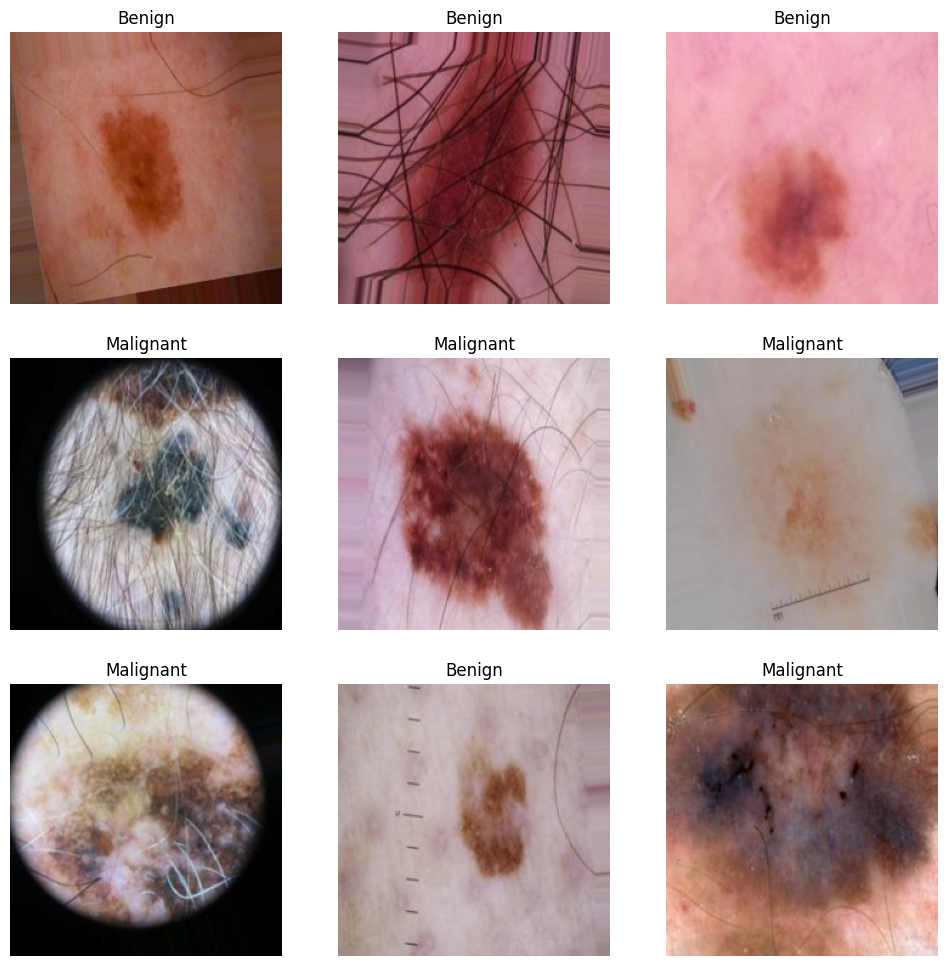

In [3]:
images,labels=next(train_generator)
plt.figure(figsize=(12,12))
for i in range(9):
    plt.subplot(3,3,1+i)
    plt.imshow(images[i])
    plt.title('Benign' if labels[i]==0 else 'Malignant')
    plt.axis('off')
plt.show()

## Build CNN Model

In [11]:
model = Sequential([
    # 1st convolution layer: units,stride size,if img=relu
    Conv2D(128,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D((2,2)),
    # 2nd convolution layer
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    # 3rd convolution layer
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D((2,2)),
    # classification
    Flatten(),
    # fully connected
    Dense(512,activation='relu'),
    Dropout(0.5),
    # if binary=sigmoid, multiple=softmax
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 222, 222, 128)       │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 111, 111, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 109, 109, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 52, 52, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 26, 26, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 21632)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │      11,076,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,172,449 (42.62 MB)

 Trainable params: 11,172,449 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

## Train and Evaluate Model

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
 
print("Configuring callbacks...")
 
early_stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=8,  # More patient
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001
)
 
lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)
 
print("Starting training...")
print(f"Training: {train_generator.samples} | Validation: {val_generator.samples}")
 
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=50,  # Increased for large dataset
    validation_data=val_generator,
    callbacks=[early_stopping, lr_schedule],
    verbose=1
)
 
print("\n Training complete!")

Configuring callbacks...
Starting training...
Training: 9265 | Validation: 2614
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


289/289 ━━━━━━━━━━━━━━━━━━━━ 132s 411ms/step - accuracy: 0.6441 - loss: 0.6394 - val_accuracy: 0.6947 - val_loss: 0.5963 - learning_rate: 0.0010
Epoch 2/50
  1/289 ━━━━━━━━━━━━━━━━━━━━ 26s 90ms/step - accuracy: 0.7188 - loss: 0.6116

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


289/289 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7188 - loss: 0.6116 - val_accuracy: 0.7131 - val_loss: 0.5899 - learning_rate: 0.0010
Epoch 3/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 121s 407ms/step - accuracy: 0.7627 - loss: 0.4996 - val_accuracy: 0.8386 - val_loss: 0.3823 - learning_rate: 0.0010
Epoch 4/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8125 - loss: 0.3578 - val_accuracy: 0.8382 - val_loss: 0.3800 - learning_rate: 0.0010
Epoch 5/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 122s 413ms/step - accuracy: 0.8234 - loss: 0.4070 - val_accuracy: 0.8263 - val_loss: 0.3909 - learning_rate: 0.0010
Epoch 6/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7812 - loss: 0.4710 - val_accuracy: 0.8179 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 7/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 122s 412ms/step - accuracy: 0.8263 - loss: 0.3992 - val_accuracy: 0.8344 - val_loss: 0.3963 - learning_rate: 0.0010
Epoch 8/50
  1/289 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.8125 - loss: 0.4


EVALUATING MODEL ON TEST SET
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 382ms/step - accuracy: 0.9067 - loss: 0.2368

RESULTS
Training Accuracy:    93.75%
Validation Accuracy:  87.18%
Test Accuracy:        90.40%

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9016    0.9070    0.9043      1000
   Malignant     0.9064    0.9010    0.9037      1000

    accuracy                         0.9040      2000
   macro avg     0.9040    0.9040    0.9040      2000
weighted avg     0.9040    0.9040    0.9040      2000


Confusion Matrix:
                 Predicted
                Benign Malignant
Actual Benign       907        93
       Malignant     99       901


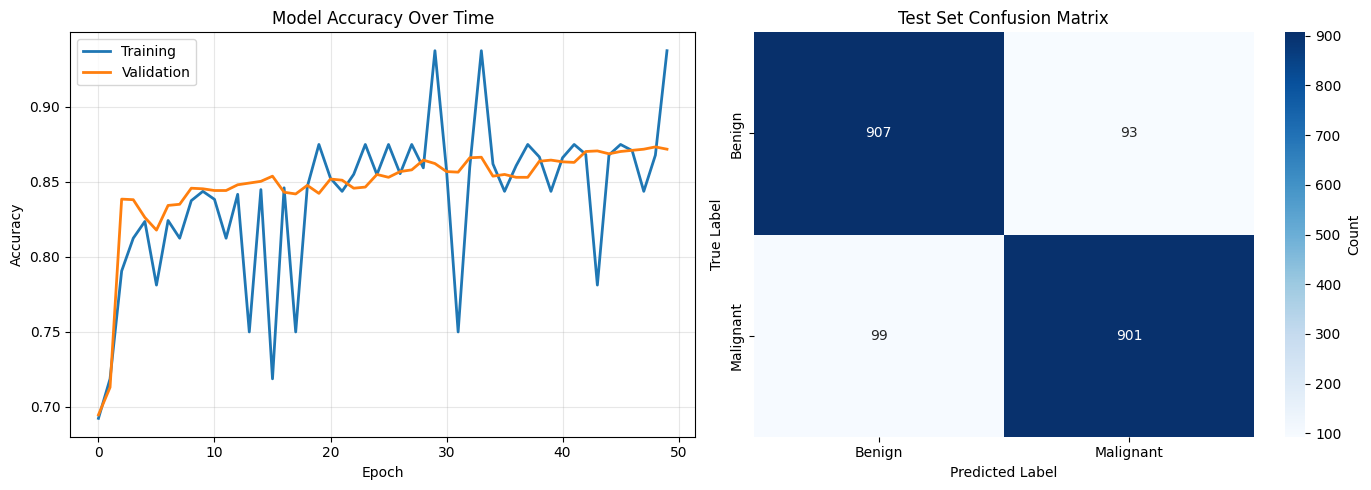


Evaluation complete!


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Save model
model.save('skin_cancer_model.h5')

print("\n" + "="*60)
print("EVALUATING MODEL ON TEST SET")
print("="*60)
 
# Evaluate
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
 
# Predictions
test_pred = model.predict(test_generator, verbose=0)
test_pred_labels = (test_pred > 0.5).astype('int32').flatten()
test_true_labels = test_generator.classes
 
# Results
print("\n" + "="*60)
print("RESULTS")
print("="*60)
print(f"Training Accuracy:   {history.history['accuracy'][-1]*100:6.2f}%")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]*100:6.2f}%")
print(f"Test Accuracy:       {test_accuracy*100:6.2f}%")
print("="*60)
 
# Classification report
print("\nClassification Report:")
print(classification_report(
    test_true_labels, test_pred_labels,
    target_names=['Benign', 'Malignant'], digits=4
))
 
# Confusion matrix
cm = confusion_matrix(test_true_labels, test_pred_labels)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                Benign Malignant")
print(f"Actual Benign    {cm[0,0]:6d}    {cm[0,1]:6d}")
print(f"       Malignant {cm[1,0]:6d}    {cm[1,1]:6d}")
 
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Training history
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant'],
    ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Test Set Confusion Matrix')
 
plt.tight_layout()
plt.show()
 
print("\nEvaluation complete!")

## Prediction system

In [19]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load the entire model
model = load_model('/kaggle/working/skin_cancer_model.h5')


def predict_skin_cancer(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))  # Load Image
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make Prediction
    prediction = model.predict(img_array)
    class_label = "Malignant" if prediction > 0.5 else "Benign"
    
    # Show Image with Prediction
    plt.imshow(img)
    plt.title(f"Predicted: {class_label}")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step


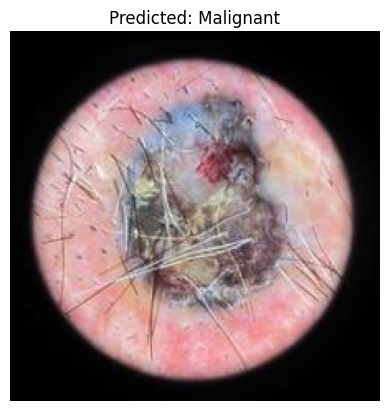

In [20]:
# Test on new image
predict_skin_cancer("/kaggle/input/melanoma-cancer-dataset/test/Malignant/5616.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


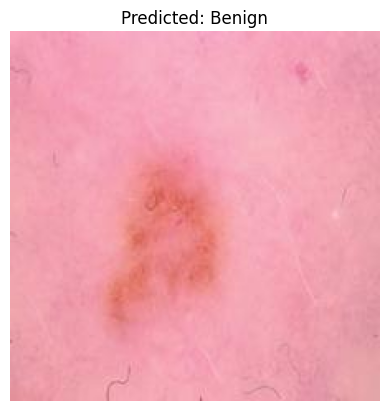

In [21]:
# Test on new image
predict_skin_cancer("/kaggle/input/melanoma-cancer-dataset/train/Benign/1004.jpg", model)